In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.interpolate import PchipInterpolator


def extract_data(filedir):
    files = os.listdir(filedir)
    df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
    df_list = [df.drop(0) for df in df_list]
    df_list = [df.drop(df.columns[list(range(-1, -9, -1))], axis=1) for df in df_list]
    data = pd.concat(df_list, ignore_index=True)    
    return data


dir1 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data1_83"
dir2 = "F:/IMU_computational_ethology/Data/2mouse_imu_83label/Data2_e8"


data1 = extract_data(dir1)
data2 = extract_data(dir2)

print(data1.shape)
print(data2.shape)

def time_transform(arr):

    arr = np.array([t.replace(":", ".").split(".") for t in arr], dtype=float)
    secs = arr[:,0]*3600 + arr[:,1]*60 + arr[:,2] + arr[:,3]/1000
    return secs

time_onchip1 = time_transform([x.split(" ", 2)[2] for x in data1[2]])
time_onchip2 = time_transform([x.split(" ", 2)[2] for x in data2[2]])


time_sys1 = time_transform(data1[0])
time_sys2 = time_transform(data2[0])

#测试掉帧
t1 = time_onchip1
t2 = time_onchip2


def frameloss_test(t):
    fl_count = 0
    lostframes = 0 
    for i in range(1, len(t)):
        if float(t[i]) - float(t[i-1]) >= 0.02:
            fl_count += 1
            lostframes += int((t[i] - t[i-1]) / 0.01) - 1
            #print(f"Frame loss between {i-1} and {i}: {t[i] - t[i-1]:.3f} seconds")        
    print(f"frame loss count: {fl_count}")
    print(f"total lost frames: {lostframes}")

frameloss_test(t1)
frameloss_test(t2)



def align_imu(data):
    """
    data: ndarray, 列0=系统时间, 列2=片上时间, 列3:15=信号(12通道)
    返回: t_new, out, fs, drift
    """
    # 强制数值化，避免字符串输入
    ts = data[:, 0]
    ts = np.array([t.replace(":", ".").split(".") for t in ts], dtype=float)
    ts = ts[:,0]*3600 + ts[:,1]*60 + ts[:,2] + ts[:,3]/1000
    
    tc = data[:, 2]
    tc = [x.split(" ", 2)[2] for x in tc]
    tc = np.array([t.replace(":", ".").split(".") for t in tc], dtype=float)
    tc = tc[:,0]*3600 + tc[:,1]*60 + tc[:,2] + tc[:,3]/1000

    sig = data[:, 3:15].astype(np.float64)
    
    # 1. 清洗片上时间异常
    dt = np.diff(tc)
    ok = np.concatenate(([True], (dt > 0) & (dt < 0.5)))
    ts, tc, sig = ts[ok], tc[ok], sig[ok]
    
    # 2. 晶振频偏拟合
    k, b = np.polyfit(ts, tc, 1)
    fs = 100.0 * k
    drift = (1.0 - k) * 100
    
    # 3. 反解平滑真实时间轴
    t_est = (tc - b) / k
    
    # 4. 等间隔目标轴
    dt = 1.0 / fs
    t_new = np.arange(t_est[0], t_est[-1] + dt/2, dt)
    
    out = np.zeros((len(t_new), sig.shape[1]))
    for i in range(sig.shape[1]):
        pchip = PchipInterpolator(t_est, sig[:, i])
        out[:, i] = pchip(t_new)
    
    return t_new, out, sig, fs, drift, t_est

t_new1, sig1, sig_ori1, fs1, drift1, t_est1 = align_imu(data1.values)
t_new2, sig2, sig_ori2, fs2, drift2, t_est2 = align_imu(data2.values)
t_new1 = t_new1-t_new1[0]
t_new2 = t_new2-t_new2[0]

ta = t_new1 - 6.6
tb = t_new2 - 6.6
ta_p = ta[ta >= 0]
imu_a = sig1[-len(ta_p):]
tb_p = tb[tb >= 0]
imu_b = sig2[-len(tb_p):]

#数据预处理
import numpy as np

def preprocess_segment(data):
    """
    单段 9 轴 IMU 预处理。
    
    输入
    ----
    data : np.ndarray, shape (n, 9)
        列顺序: [ax, ay, az, wx, wy, wz, roll, pitch, yaw]
        单位: 加速度(g), 角速度(°/s), 角度(°)
        
    输出
    ----
    np.ndarray, shape (n, 12)
        列顺序: [aGx, aGy, aGz, anGx, anGy, anGz, wx, wy, wz, roll, pitch, yaw]
    """
    a_raw = data[:, 0:3].astype(float)
    w_raw = data[:, 3:6].astype(float)
    r_deg = data[:, 6:9].astype(float)

    # 1. 陀螺仪零偏：整段中位数（角速度理论上均值为0）
    w = w_raw - np.median(w_raw, axis=0)

    # 2. 欧拉角 -> 旋转矩阵 R (head -> Earth, ZYX 内旋: yaw→pitch→roll)
    #    如果传感器角度顺序不同，请修改此矩阵
    r = np.radians(r_deg)
    cr, sr = np.cos(r[:, 0]), np.sin(r[:, 0])   # roll
    cp, sp = np.cos(r[:, 1]), np.sin(r[:, 1])   # pitch
    cy, sy = np.cos(r[:, 2]), np.sin(r[:, 2])   # yaw

    R = np.zeros((len(data), 3, 3))
    R[:, 0, 0] = cy * cp
    R[:, 0, 1] = cy * sp * sr - sy * cr
    R[:, 0, 2] = cy * sp * cr + sy * sr
    R[:, 1, 0] = sy * cp
    R[:, 1, 1] = sy * sp * sr + cy * cr
    R[:, 1, 2] = sy * sp * cr - cy * sr
    R[:, 2, 0] = -sp
    R[:, 2, 1] = cp * sr
    R[:, 2, 2] = cp * cr

    # 3. 头部参考系中的重力分量 aG = R^T · [0, 0, 1]
    aG = np.einsum('nij,j->ni', R.transpose(0, 2, 1), np.array([0., 0., 1.]))

    # 验证：aG 模长必须恒为 1.0。若报错，说明角度顺序/定义与代码不符
    assert np.allclose(np.linalg.norm(aG, axis=1), 1.0, atol=0.05), \
        "aG 模长不恒为 1g，请检查 roll/pitch/yaw 是否为 ZYX 内旋顺序"

    # 4. 加速度零偏：利用 anG 应近似零均值的特性
    #    a_raw = aG + anG_true + bias  =>  a_raw - aG = anG_true + bias
    #    取中位数即可分离出 bias（假设真实运动加速度 anG_true 的中位数为0）
    acc_bias = np.median(a_raw - aG, axis=0)
    a = a_raw - acc_bias

    # 5. 非重力加速度
    anG = a - aG
    list_new = np.concatenate([aG, anG, w, r_deg, a], axis=1)

    return list_new



C:\Users\Shubai\AppData\Local\Temp\ipykernel_9476\2878687962.py:13: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_9476\2878687962.py:13: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shubai\AppData\Local\Temp\ipykernel_9476\2878687962.py:13: DtypeWarning: Columns (3,4,5,6,7,8,9,10,11,12,13,14,15,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list = [pd.read_csv(os.path.join(filedir, f), header=None, names=list(range(23))) for f in files if f.endswith('.csv')]
C:\Users\Shub

(461628, 15)
(460404, 15)
frame loss count: 223
total lost frames: 93373806
frame loss count: 335
total lost frames: 2699


In [2]:
imu_preprocessed1 = preprocess_segment(imu_a)
imu_preprocessed2 = preprocess_segment(imu_b)

In [3]:
def window_split(data, window_size, step_size):
    """
    序列切割：滑动窗口提取子序列
    data: 二维列表，形状为 n行 x 6列
    window_size: 窗长（每个窗口包含多少行）
    step_size: 步长（每次滑动多少行）
    返回: 新列表，每个元素是一个窗口
    """
    result = []
    for i in range(0, len(data), step_size):
        window = data[i : i + window_size]
        if len(window) == window_size:      # 只保留完整窗口
            result.append(window)
    return result

In [37]:
windows1 = window_split(imu_preprocessed1, 50,10)
windows2 = window_split(imu_preprocessed2, 50,10)

In [38]:
#特征提取
import numpy as np
from scipy import stats
from scipy.fft import fft


def extract_window_features(window, start_idx):
    """
    对9轴信号窗口提取特征，返回1维向量
    
    参数:
        window:  形状 (window_len, 9) 的 numpy 数组
        start_idx:  窗口在原始数据中的起始行索引
    
    返回:
        feat_vec:  1维 numpy 向量
    """
    n_samples, n_axes = window.shape
    feat_list = []
    
    # ========== 3) 信号时间位置 ==========
    end_idx = start_idx + n_samples - 1
    center_idx = (start_idx + end_idx) / 2
    feat_list.extend([start_idx, end_idx, center_idx])
    
    # ========== 逐轴特征 ==========
    for axis in range(n_axes):
        s = window[:, axis]
        
        # 时域统计
        feat_list.append(np.mean(s))
        feat_list.append(np.std(s, ddof=1))
        feat_list.append(np.var(s, ddof=1))
        feat_list.append(np.max(s))
        feat_list.append(np.min(s))
        feat_list.append(np.max(s) - np.min(s))          # 极差
        feat_list.append(np.median(s))
        feat_list.append(np.sqrt(np.mean(s**2)))          # RMS
        feat_list.append(np.sum(s**2))                    # 能量
        feat_list.append(stats.skew(s))                   # 偏度
        feat_list.append(stats.kurtosis(s))              # 峰度
        feat_list.append(np.sum((s[:-1] * s[1:]) < 0))   # 过零率
        
        # 一阶差分
        diff = np.diff(s)
        feat_list.append(np.mean(diff))
        feat_list.append(np.std(diff, ddof=1))
        feat_list.append(np.max(diff))
        feat_list.append(np.min(diff))
        feat_list.append(np.max(diff) - np.min(diff))     # 差分极差
        
        # 二阶差分
        diff2 = np.diff(s, n=2)
        feat_list.append(np.mean(diff2))
        feat_list.append(np.std(diff2, ddof=1))
        
        # 频域 (FFT)
        fft_vals = fft(s)
        fft_amp = np.abs(fft_vals[:n_samples // 2])
        fft_amp = fft_amp / (n_samples / 2)
        freqs = np.fft.fftfreq(n_samples, d=1.0)[:n_samples // 2]
        
        if len(fft_amp) > 0 and np.max(fft_amp) > 0:
            feat_list.append(np.sum(fft_amp**2))                          # 频谱能量
            feat_list.append(stats.entropy(fft_amp + 1e-12))               # 频谱熵
            feat_list.append(freqs[np.argmax(fft_amp)])                    # 主频
            feat_list.append(np.mean(fft_amp))                             # 频谱均值
            feat_list.append(np.std(fft_amp))                              # 频谱标准差
        else:
            feat_list.extend([0.0, 0.0, 0.0, 0.0, 0.0])
    
    # ========== 跨轴特征 ==========
    corr_matrix = np.corrcoef(window.T)
    mask = np.triu_indices_from(corr_matrix, k=1)
    feat_list.append(np.mean(corr_matrix[mask]))
    feat_list.append(np.max(corr_matrix[mask]))
    feat_list.append(np.min(corr_matrix[mask]))
    
    return np.array(feat_list, dtype=np.float32)


# ========== 使用示例 ==========
if __name__ == '__main__':
    np.random.seed(42)
    
    window = np.random.randn(100, 9)
    feat_vec = extract_window_features(window, start_idx=250)
    
    print(f"特征向量形状: {feat_vec.shape}")
    print(f"特征向量长度: {len(feat_vec)}")
    print(f"前10个值: {feat_vec[:10]}")

特征向量形状: (222,)
特征向量长度: 222
前10个值: [ 2.5000000e+02  3.4900000e+02  2.9950000e+02  3.4371946e-02
  8.8631594e-01  7.8555590e-01  2.1898029e+00 -1.7131345e+00
  3.9029374e+00  7.7643134e-02]


In [39]:
#运行提取、降维
features1 =  []
for s in windows1[1200:4800]:
    feat = extract_window_features(s, 120)
    features1.append(feat)

features_pca1 = dim_reduction(features1)


#运行提取、降维
features2 =  []
for s in windows2[1200:4800]:
    feat = extract_window_features(s, 120)
    features2.append(feat)

features_pca2 = dim_reduction(features2)

In [33]:
features1 =  []
for s in windows1[1200:1400]:
    feat = extract_window_features(s, 120)
    features1.append(feat)
print(features1[0])

{'start_idx': 120, 'end_idx': 139, 'center_idx': 129.5, 'axis0_mean': np.float64(-0.7175551369088741), 'axis0_std': np.float64(0.01685871536354298), 'axis0_var': np.float64(0.00028421628370896014), 'axis0_max': np.float64(-0.6921053912783227), 'axis0_min': np.float64(-0.7598275903966273), 'axis0_range': np.float64(0.06772219911830457), 'axis0_median': np.float64(-0.716301848818373), 'axis0_rms': np.float64(0.7177432549135078), 'axis0_energy': np.float64(10.303107599476734), 'axis0_skew': np.float64(-0.690231091818677), 'axis0_kurt': np.float64(0.225170326781718), 'axis0_zcr': np.int64(0), 'axis0_diff_mean': np.float64(0.003564326269384451), 'axis0_diff_std': np.float64(0.008231430897714175), 'axis0_diff_max': np.float64(0.018575843141017345), 'axis0_diff_min': np.float64(-0.0064449715185485035), 'axis0_diff_range': np.float64(0.02502081465956585), 'axis0_diff2_mean': np.float64(-0.00026949205773741443), 'axis0_diff2_std': np.float64(0.004653021843316293), 'axis0_fft_energy': np.float64

k= 1, BIC=300841.13
k= 2, BIC=333393.49
k= 3, BIC=345035.16
k= 4, BIC=346778.74
k= 5, BIC=357315.14
k= 6, BIC=370313.81
k= 7, BIC=375327.26
k= 8, BIC=387343.77
k= 9, BIC=453876.01
k=10, BIC=458858.59

BIC选择最佳k = 1


d:\Anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


ValueError: 'c' argument has 3600 elements, which is inconsistent with 'x' and 'y' with size 2400.

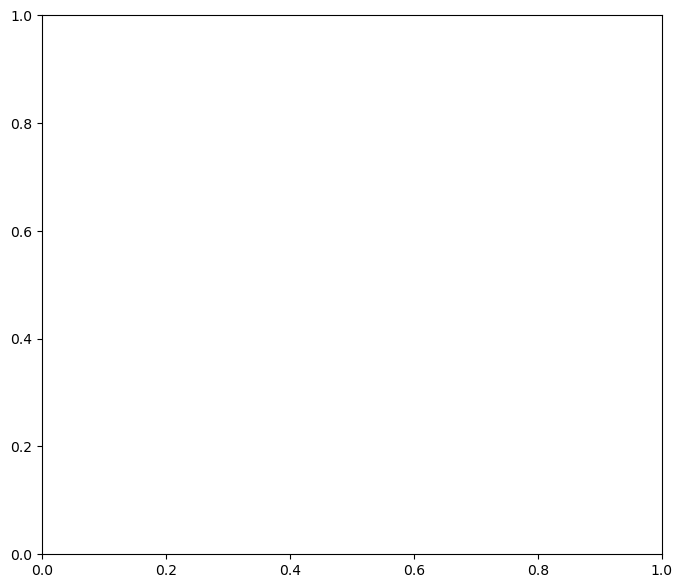

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import umap

# ========== 1. 读取你的30维数据 ==========
np.random.seed(42)
X1 = features_pca1

# ========== 2. BIC选择最佳聚类数 ==========
k_range = range(1, 11)
bics = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm.fit(X1)
    bics.append(gmm.bic(X))
    print(f"k={k:2d}, BIC={bics[-1]:.2f}")

best_k = k_range[np.argmin(bics)]
print(f"\nBIC选择最佳k = {best_k}")

# 用最佳k重新拟合GMM
best_gmm = GaussianMixture(n_components=best_k, random_state=42, n_init=5)
best_gmm.fit(X1)
labels = best_gmm.predict(X1)

# ========== 3. UMAP降维 + 默认色板散点图 ==========
X1_umap = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(
    X1_umap[:, 0], X1_umap[:, 1],
    c=labels, cmap='tab10', s=30, alpha=0.8, edgecolors='none'
)
plt.title(f'UMAP GMM Clustering (k={best_k}, selected by BIC)', fontsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
cbar = plt.colorbar(scatter, label='Cluster')
cbar.set_ticks(np.unique(labels))
plt.tight_layout()
plt.show()